In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd

df = pd.read_csv('../../Data/raw/ecommerce_customer_churn_dataset.csv')

In [94]:
num_cols = df.select_dtypes(include="number").columns

num_summary = df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
num_summary["missing_count"] = df[num_cols].isna().sum()
num_summary["missing_pct"] = (df[num_cols].isna().mean() * 100).round(2)
num_summary["skew"] = df[num_cols].skew(numeric_only=True).round(2)

num_summary.sort_values("std", ascending=False)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct,skew
Credit_Balance,44500.0,1966.233258,1225.072166,0.00,1049.0000,1896.000,2791.00,7197.000000,5500,11.00,0.38
Lifetime_Value,50000.0,1440.626292,907.249443,0.00,789.8175,1243.415,1874.00,8987.240000,0,0.00,1.45
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.0500,112.970,144.44,9666.379178,0,0.00,42.36
Days_Since_Last_Purchase,47000.0,29.792872,29.695062,0.00,9.0000,21.000,41.00,287.000000,3000,6.00,1.99
Discount_Usage_Rate,46500.0,41.997485,21.373642,0.24,25.3000,40.200,57.00,116.640000,3500,7.00,0.37
Social_Media_Engagement_Score,44000.0,29.364466,20.574021,0.00,13.2000,27.600,43.10,100.000000,6000,12.00,0.50
Cart_Abandonment_Rate,50000.0,57.079973,16.282723,0.00,46.4000,58.100,68.70,143.743350,0,0.00,-0.26
Email_Open_Rate,47472.0,20.937980,14.252561,0.00,9.9000,19.700,30.40,91.700000,2528,5.06,0.49
Age,47505.0,37.802968,11.834668,5.00,29.0000,38.000,46.00,200.000000,2495,4.99,0.95
Session_Duration_Avg,46601.0,27.660754,10.871013,1.00,19.7000,26.800,34.70,75.600000,3399,6.80,0.40


### 1) Age ไม่ถุูกต้องตามหลักการ มีคนอายมากกว่า มี Outlier

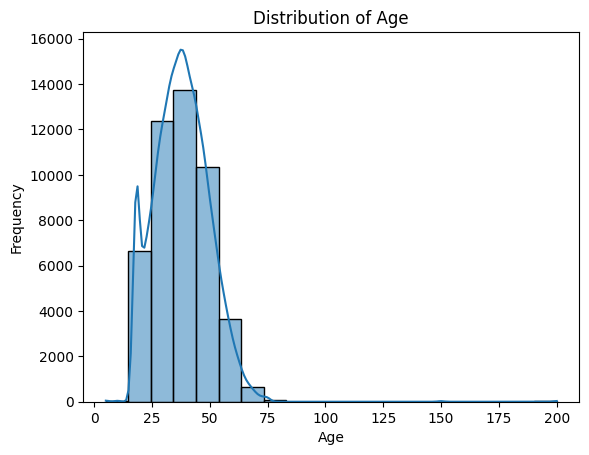

Outlier Ages: [150. 200.]
Number of outliers: 20
Outlier percentage: 0.04


In [95]:
df["Age"].min(), df["Age"].max()

sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

outlier_age = df[df["Age"] > 100]["Age"].unique()
print("Outlier Ages:", outlier_age)

print("Number of outliers:", (df["Age"] > 100).sum())
print("Outlier percentage:", (df["Age"] > 100).sum() / len(df) * 100)

In [155]:
# detect unrealistic ages
df.loc[df["Age"] > 100, "Age"] = np.nan

# impute missing age
df["Age"] = df["Age"].fillna(df["Age"].median())


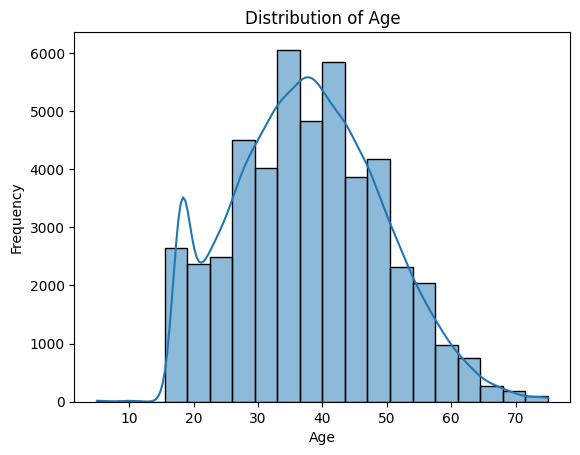

Skewness of Age after fix: 0.22302456234135462


In [97]:
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print("Skewness of Age after fix:", df["Age"].skew())
#OK DATA got fixed

ผมดําเนินการแก้ไข ข้อมูล Outlier มีสันส่วน ตํ่า ทําไห้ข้อมูลผิดเพี้ยน ผมทําการ แทนค่าด้วย ค่ากลาง Median เพื่อเกลี่ยข้อมูลไห้เป็นกลางมากที่สุด และ ลดผมจาก Outlier ให้มากที่สุด

### Member Year

In [98]:
print("Count of Membership Years less than 0:", df[df["Membership_Years"] < 0].shape[0])

Count of Membership Years less than 0: 0


#### Visual Memebr Year (Range)

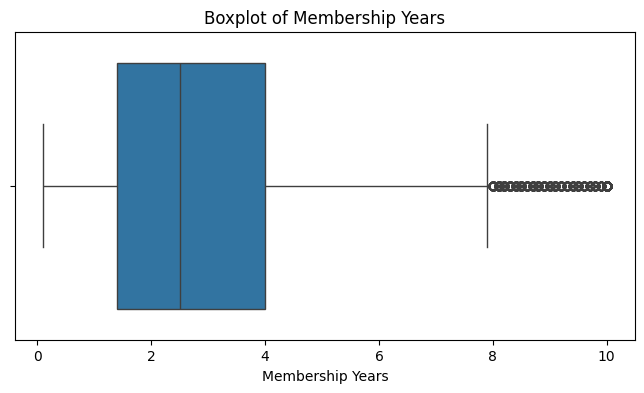

In [99]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Membership_Years"])

plt.title("Boxplot of Membership Years")
plt.xlabel("Membership Years")
plt.show()

### Login_Frequency

In [100]:
print("Login Frequency less than 0:", df[df["Login_Frequency"] < 0].shape[0])

Login Frequency less than 0: 0


#### Visual Login Frequency (Range)

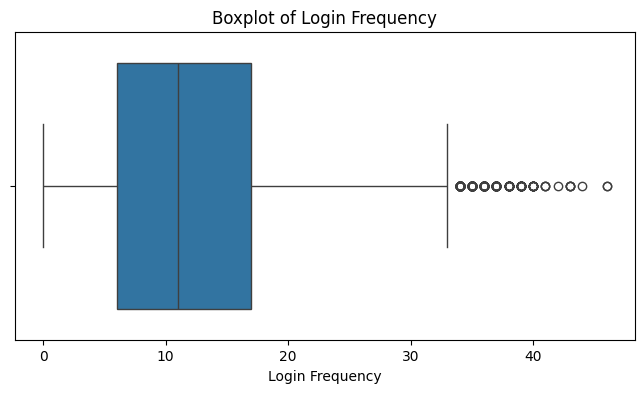

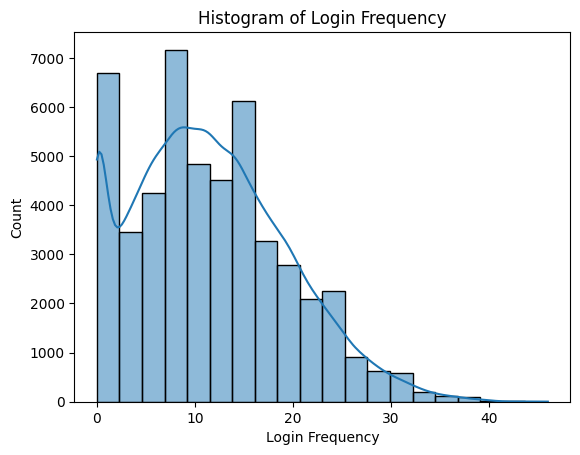

In [101]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Login_Frequency"])

plt.title("Boxplot of Login Frequency")
plt.xlabel("Login Frequency")
plt.show()

sns.histplot(df["Login_Frequency"], bins=20, kde=True)
plt.title("Histogram of Login Frequency")
plt.xlabel("Login Frequency")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='Churned', ylabel='Login_Frequency'>

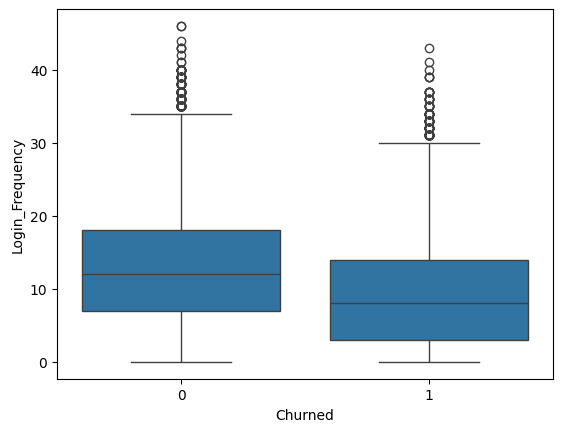

In [102]:
sns.boxplot(x="Churned", y="Login_Frequency", data=df)

Login Frequency shows a right-skewed distribution with a long tail of highly active users. 
While boxplot identifies several statistical outliers (>32 logins per month), these likely represent highly engaged users rather than data errors.

Additionally, customers who churned tend to have lower median login frequency compared to active users, suggesting that reduced platform engagement may be associated with churn behavior.

#### Session_Duration_Avg

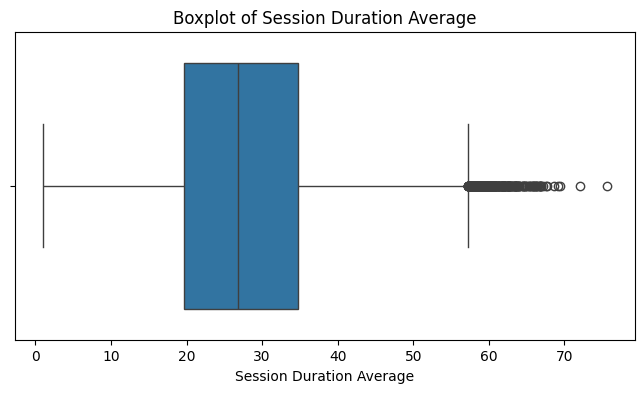

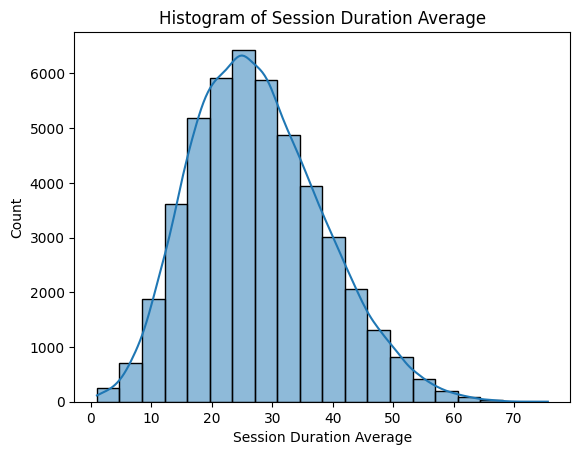

In [103]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Session_Duration_Avg"])

plt.title("Boxplot of Session Duration Average")
plt.xlabel("Session Duration Average")
plt.show()

sns.histplot(df["Session_Duration_Avg"], bins=20, kde=True)
plt.title("Histogram of Session Duration Average")
plt.xlabel("Session Duration Average")
plt.ylabel("Count")
plt.show()


#### Total_Purchases

Minimum: -13.0
Maximum: 128.70000000000002
Zero values: 9
Negative values: 40

Percentage of Total Purchases less than 0: 0.08

Each data on Total Purchases less than 0: [ -9.1  -6.  -10.4 -11.7  -3.   -1.   -2.6 -10.   -5.2  -7.   -4.   -5.
  -6.5  -7.8  -8.   -2.  -13. ]


===Old Boxplot of Total Purchases when having false values===


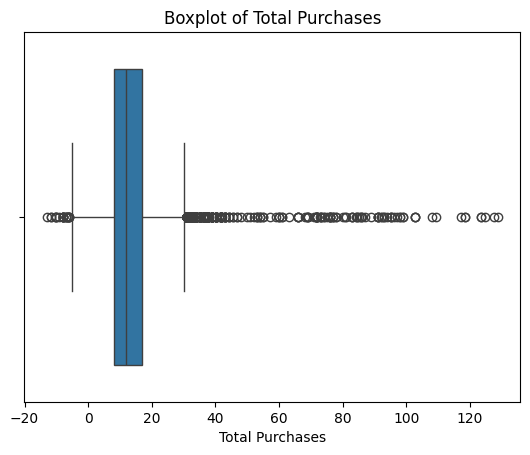

skewness of Total Purchases before fix: 2.690116792868297


In [104]:
#Invalid Total Purchases , impossible to have negative purchases
print("Minimum:", df["Total_Purchases"].min())
print("Maximum:", df["Total_Purchases"].max())
print("Zero values:", (df["Total_Purchases"] == 0).sum())
print("Negative values:", (df["Total_Purchases"] < 0).sum())

print("\nPercentage of Total Purchases less than 0:", df[df["Total_Purchases"] < 0].shape[0] / len(df) * 100)
print("\nEach data on Total Purchases less than 0:", df[df["Total_Purchases"] < 0]["Total_Purchases"].unique())

print("\n\n===Old Boxplot of Total Purchases when having false values===")
sns.boxplot(x=df["Total_Purchases"])
plt.title("Boxplot of Total Purchases")
plt.xlabel("Total Purchases")
plt.show()

print("skewness of Total Purchases before fix:", df["Total_Purchases"].skew())


- Fix Total_Purchases

In [105]:
df.loc[df["Total_Purchases"] < 0, "Total_Purchases"] = 0
print("Negative values:", (df["Total_Purchases"] < 0).sum())


Negative values: 0


### =========Fill Empty Value ==========
Goal: Clear Null Value make it less miss from truth data

In [139]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
Age                                 0
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg                0
Pages_Per_Session                   0
Cart_Abandonment_Rate               0
Wishlist_Items                      0
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase            0
Discount_Usage_Rate                 0
Returns_Rate                        0
Email_Open_Rate                     0
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
Session_Status    

In [107]:
# Convert Age to numeric first; invalid text becomes NaN
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Fill missing Age with median using assignment (more reliable than inplace on a slice)
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Remaining nulls in Age:", df["Age"].isna().sum())

Remaining nulls in Age: 0


In [108]:
from pathlib import Path

# Save cleaned dataset into Data/processed
output_dir = Path("../../Data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

clean_file_path = output_dir / "cleaned_data.csv"
df.to_csv(clean_file_path, index=False)
print(f"Cleaned data saved to {clean_file_path.resolve()}")

Cleaned data saved to /home/ppt/Desktop/DataAnalyst/Eccommerce-Customer-Behavior-Dataset-main/Data/processed/cleaned_data.csv


In [109]:
df["Membership_Years"].unique()
print("Minimum Membership Years:", df["Membership_Years"].min())
print("Minimum Session Duration Average:", df["Session_Duration_Avg"].min())


Minimum Membership Years: 0.1
Minimum Session Duration Average: 1.0


<Axes: xlabel='Session_Duration_Avg'>

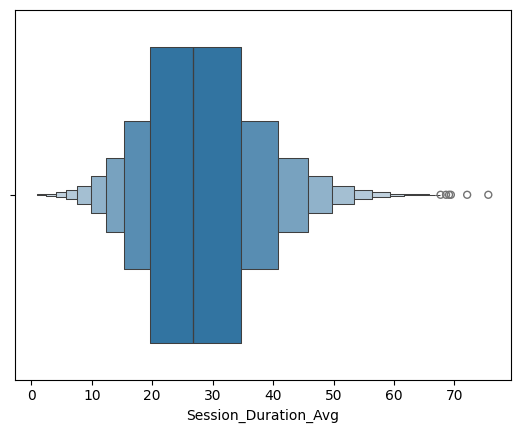

In [110]:
sns.boxenplot(x="Session_Duration_Avg", data=df)

In [111]:
print("Total missing values in Session Duration Average:", df["Session_Duration_Avg"].isna().sum())
print("\nTotal Churned when Session Duration Average is missing:", df[df["Session_Duration_Avg"].isna()]["Churned"].value_counts())

df[df["Session_Duration_Avg"].isna()].describe()

Total missing values in Session Duration Average: 3399

Total Churned when Session Duration Average is missing: Churned
0    2001
1    1398
Name: count, dtype: int64


,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,3399.000000,3399.000000,3399.000000,0.0,3184.000000,3399.000000,3111.000000,3399.000000,3399.000000,3203.000000,3174.000000,3102.000000,3132.000000,3380.000000,3160.000000,2998.000000,3083.000000,3226.000000,3399.000000,2980.000000,3399.000000
mean,37.627538,2.990746,7.208297,NaN,6.509736,71.223110,2.652845,9.612592,121.645166,29.687480,42.433106,6.637407,13.385249,6.600592,1.767722,18.677985,13.819332,2.351829,1033.302398,1434.563758,0.411297
std,11.082606,2.057920,5.687427,NaN,2.767171,8.284000,2.193023,6.371910,153.716473,28.051217,21.493315,6.652493,10.757336,2.699994,1.645305,15.449359,6.693643,1.125831,658.304660,1023.601397,0.492141
min,5.000000,0.100000,0.000000,NaN,1.000000,60.100000,0.000000,0.000000,30.000000,0.000000,0.700000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,1.400000,2.000000,NaN,4.500000,64.550000,1.000000,6.000000,87.470000,9.000000,25.320000,2.800000,4.375000,5.000000,1.000000,4.700000,9.200000,1.000000,566.410000,605.000000,0.000000
50%,37.000000,2.500000,7.000000,NaN,6.400000,69.600000,2.000000,9.000000,113.170000,22.000000,40.690000,5.300000,12.100000,6.000000,1.000000,16.950000,13.500000,2.000000,884.190000,1360.500000,0.000000
75%,45.000000,4.000000,11.000000,NaN,8.300000,76.000000,4.000000,12.000000,143.320000,41.000000,57.600000,8.900000,20.300000,8.000000,3.000000,29.300000,18.200000,3.000000,1328.350000,2144.000000,1.000000
max,75.000000,10.000000,35.000000,NaN,17.700000,142.851486,15.000000,124.800000,8711.608797,214.000000,114.720000,96.339400,64.700000,21.000000,13.000000,81.000000,41.500000,5.000000,5879.390000,6132.000000,1.000000


In [112]:
df[df["Session_Duration_Avg"].isna()][
["Login_Frequency","Membership_Years"]
].describe()

,Login_Frequency,Membership_Years
count,3399.000000,3399.000000
mean,7.208297,2.990746
std,5.687427,2.057920
min,0.000000,0.100000
25%,2.000000,1.400000
50%,7.000000,2.500000
75%,11.000000,4.000000
max,35.000000,10.000000


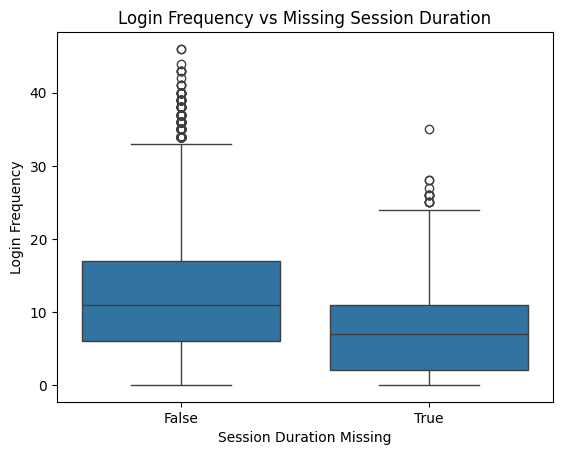

In [113]:
sns.boxplot(x=df["Session_Duration_Avg"].isna(), y=df["Login_Frequency"])
plt.title("Login Frequency vs Missing Session Duration")
plt.xlabel("Session Duration Missing")
plt.ylabel("Login Frequency")
plt.show()

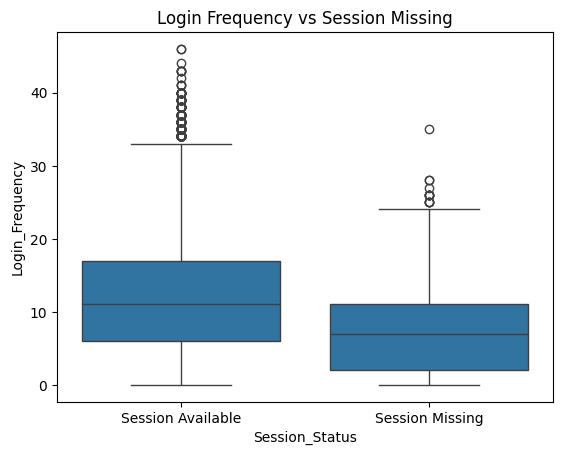

In [114]:
df["Session_Status"] = df["Session_Duration_Avg"].isna().map({
    True: "Session Missing",
    False: "Session Available"
})

sns.boxplot(
    x="Session_Status",
    y="Login_Frequency",
    data=df
)

plt.title("Login Frequency vs Session Missing")
plt.show()

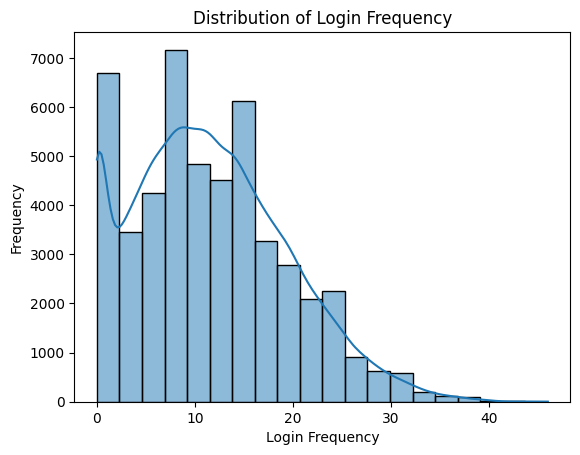

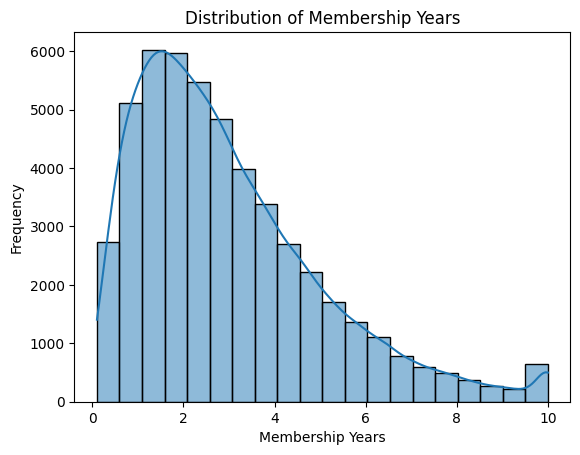

In [115]:
sns.histplot(df["Login_Frequency"], bins=20, kde=True)
plt.title("Distribution of Login Frequency")
plt.xlabel("Login Frequency")
plt.ylabel("Frequency")
plt.show()

sns.histplot(x=df["Membership_Years"], bins=20, kde=True)
plt.title("Distribution of Membership Years")
plt.xlabel("Membership Years")
plt.ylabel("Frequency")
plt.show()

In [116]:
df[df["Session_Duration_Avg"].isna()]["Churned"].value_counts(normalize=True)

Churned
0    0.588703
1    0.411297
Name: proportion, dtype: float64

- ลูกค้ากลุ่มนี้ login ประมาณ 7 ครั้ง / เดือน ถือว่า ไม่สูง

- ลูกค้ากลุ่มนี้เป็นสมาชิกไม่นาน เมื่อเทียบกับmax = 10 ปี

### Insight (from Missing Session_Duration_Avg)
ลูกค้าที่มี session duration หาย >> มักเป็นลูกค้าใหม่ + activity ต่ำ
หมายถึง: ลูกค้า engagement ต่ำ

### Impute missing Session Duration Average with median

In [117]:
# Impute missing Session Duration Average with median
df["Session_Duration_Avg"] = df["Session_Duration_Avg"].fillna(
    df["Session_Duration_Avg"].median()
)

print("Total null value on Session Duration Average after imputation:", df["Session_Duration_Avg"].isna().sum())

Total null value on Session Duration Average after imputation: 0


### Impute missing Pages_Per_Session

In [118]:
df[df["Pages_Per_Session"].isna()][
["Login_Frequency","Membership_Years", "Total_Purchases","Average_Order_Value", "Wishlist_Items"]
].describe()

,Login_Frequency,Membership_Years,Total_Purchases,Average_Order_Value,Wishlist_Items
count,3000.000000,3000.000000,3000.000000,3000.000000,2744.000000
mean,11.675667,2.980321,13.202367,123.103407,4.274417
std,7.842723,2.047243,6.849732,148.324214,3.154334
min,0.000000,0.100000,0.000000,27.700000,0.000000
25%,6.000000,1.500000,8.000000,87.487500,2.000000
50%,11.000000,2.600000,12.000000,113.690000,4.000000
75%,17.000000,4.000000,17.000000,147.972500,6.000000
max,43.000000,10.000000,84.500000,7862.050069,18.000000


In [119]:
df["Pages_Status"] = df["Pages_Per_Session"].isna().map({
    True: "Missing",
    False: "Available"
})

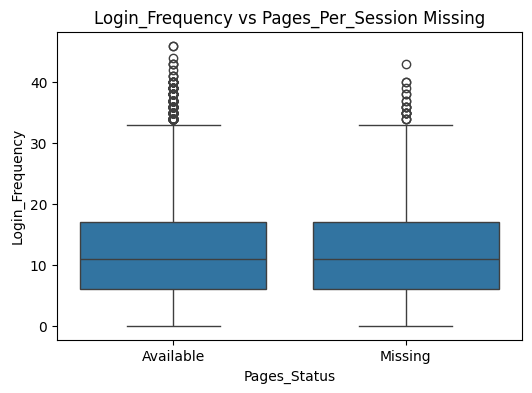

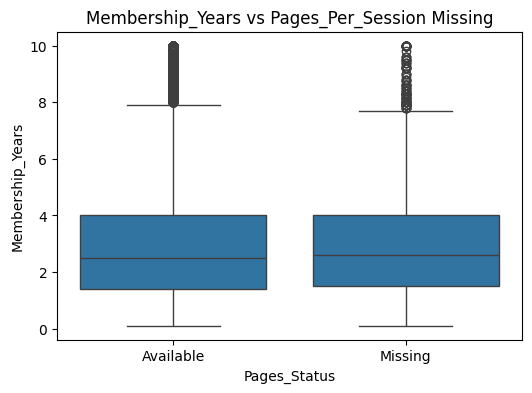

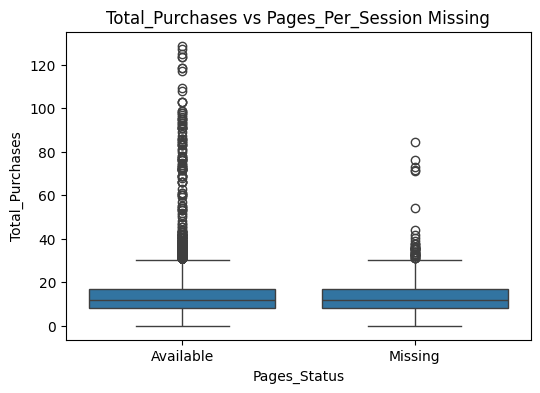

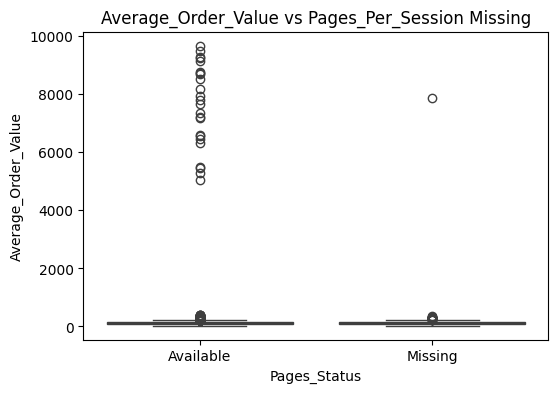

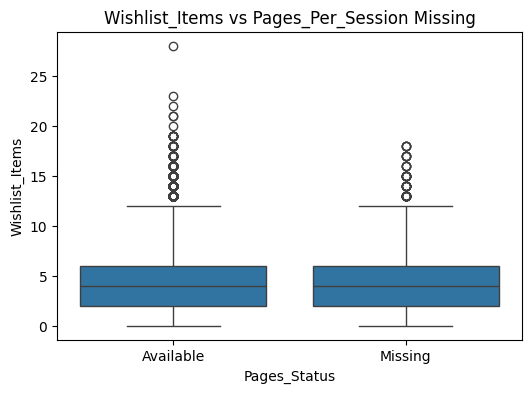

In [120]:
cols = [
    "Login_Frequency",
    "Membership_Years",
    "Total_Purchases",
    "Average_Order_Value",
    "Wishlist_Items"
]

for col in cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x="Pages_Status",
        y=col,
        data=df
    )
    
    plt.title(f"{col} vs Pages_Per_Session Missing")
    
    plt.show()

Missing values in Pages_Per_Session do not show significant behavioral differences 
compared to non-missing records across key engagement metrics such as login frequency,
membership duration, and purchase behavior. 

This suggests that the missing values may occur randomly rather than due to user activity.
Therefore, median imputation was applied for handling the missing data.

Pages_Per_Session missing
ไม่ได้สัมพันธ์กับ
- engagement
- membership
- purchasing behavior

Missing Completely At Random (MCAR)

In [121]:
# Impute missing Pages Per Session with median
df["Pages_Per_Session"] = df["Pages_Per_Session"].fillna(
    df["Pages_Per_Session"].median()
)

### Impute missing Wishlist_Items

In [122]:
df[df["Wishlist_Items"].isna()][
["Login_Frequency","Membership_Years", "Total_Purchases","Average_Order_Value", "Days_Since_Last_Purchase", "Lifetime_Value","Mobile_App_Usage", "Social_Media_Engagement_Score", "Email_Open_Rate", "Session_Duration_Avg","Pages_Per_Session"]
].describe()

,Login_Frequency,Membership_Years,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Lifetime_Value,Mobile_App_Usage,Social_Media_Engagement_Score,Email_Open_Rate,Session_Duration_Avg,Pages_Per_Session
count,4000.00000,4000.000000,4000.00000,4000.000000,3750.000000,4000.000000,3579.000000,3543.000000,3809.000000,4000.000000,4000.00000
mean,11.48150,3.004738,12.94910,119.713455,29.432267,1428.895583,19.168483,29.074005,20.666632,27.350325,8.67720
std,7.74701,2.098692,6.68302,44.381595,29.179553,889.669627,9.414793,20.389657,14.378562,10.504159,3.66863
min,0.00000,0.100000,0.00000,31.760000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.00000
25%,5.00000,1.400000,8.00000,87.037500,9.000000,794.545000,12.400000,13.000000,9.300000,20.000000,6.10000
50%,11.00000,2.500000,12.00000,113.795000,20.000000,1247.270000,18.300000,27.600000,19.300000,26.800000,8.40000
75%,16.00000,4.100000,16.90000,145.055000,41.000000,1864.377500,25.200000,42.400000,30.000000,33.600000,11.00000
max,43.00000,10.000000,102.70000,383.140000,257.000000,8243.530000,53.800000,100.000000,81.200000,66.800000,21.60000


In [123]:
df["Wishlist_item_Status"] = df["Wishlist_Items"].isna().map({
    True: "Missing",
    False: "Available"
})

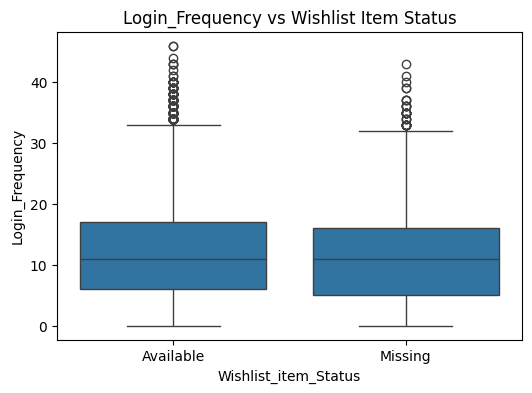

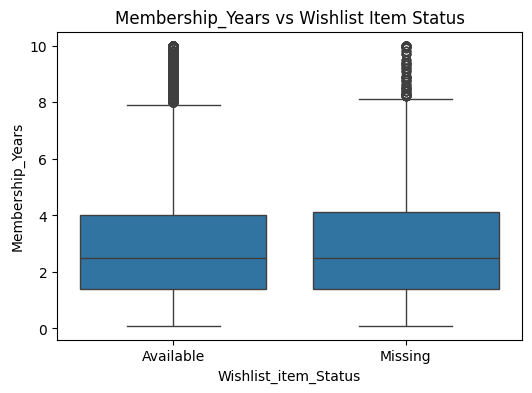

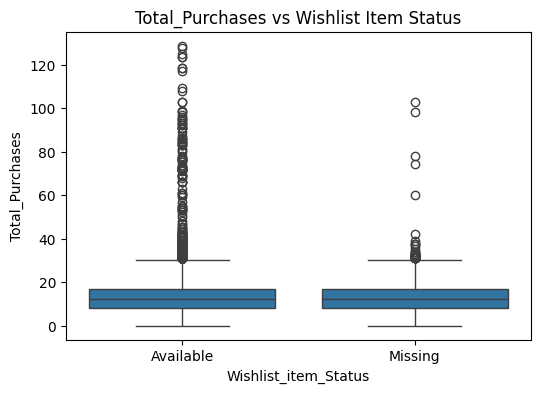

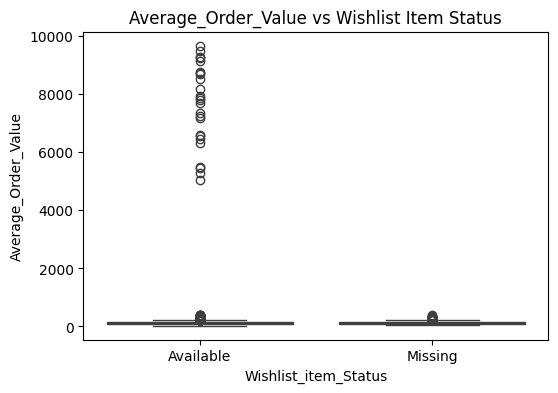

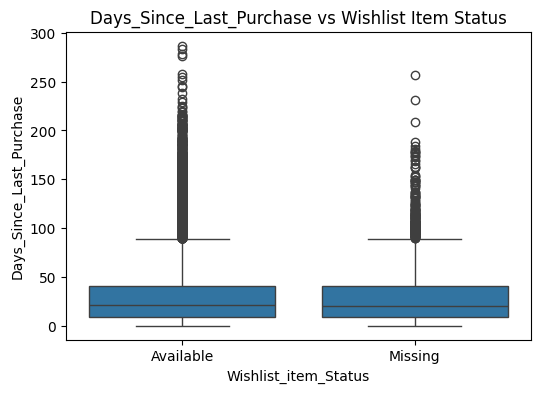

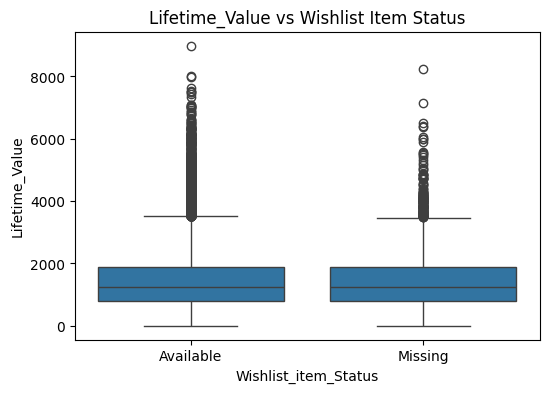

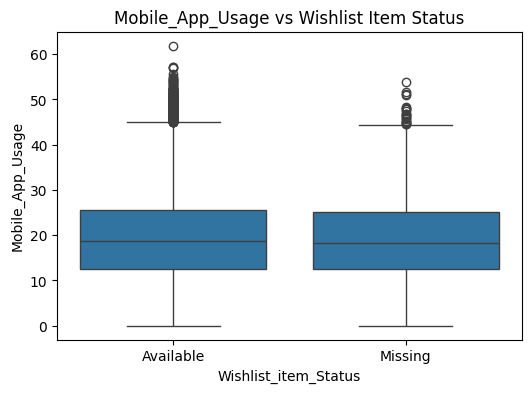

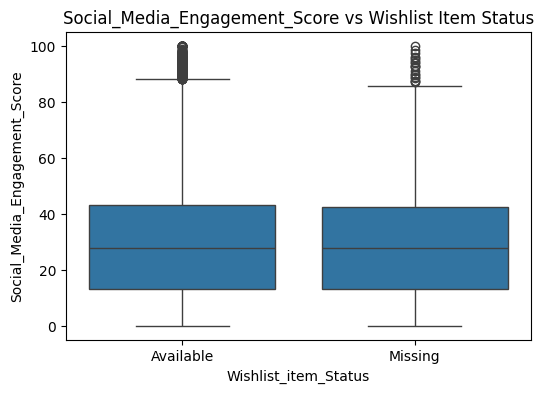

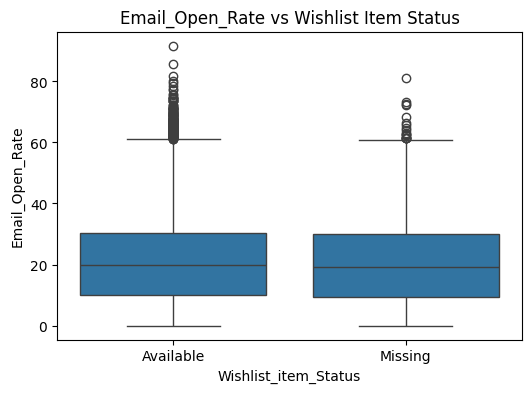

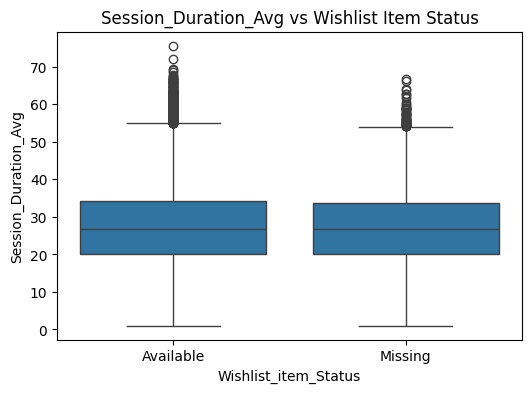

In [124]:
features = [
    "Login_Frequency",
    "Membership_Years",
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Lifetime_Value",
    "Mobile_App_Usage",
    "Social_Media_Engagement_Score",
    "Email_Open_Rate",
    "Session_Duration_Avg"
]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="Wishlist_item_Status",
        y=feature,
        data=df
    )

    plt.title(f"{feature} vs Wishlist Item Status")
    plt.show()


Pages_Per_Session Missing Analysis

Compared distributions of multiple behavioral features between
records with missing and non-missing Pages_Per_Session.

Features checked:
Login_Frequency, Membership_Years, Total_Purchases,
Average_Order_Value, Days_Since_Last_Purchase,
Lifetime_Value, Mobile_App_Usage,
Social_Media_Engagement_Score, Email_Open_Rate,
Session_Duration_Avg.

Result:
Distributions were nearly identical (similar median and IQR).

Conclusion:
Missing values are likely MCAR (Missing Completely At Random).

Action:
Filled missing values using median imputation.



In [125]:
# Impute missing Wishlist Items with median
df["Wishlist_Items"] = df["Wishlist_Items"].fillna(
    df["Wishlist_Items"].median()
)

### Impute missing Days_Since_Last_Purchase

In [126]:
df[df["Days_Since_Last_Purchase"].isna()]["Total_Purchases"].describe()

count    3000.000000
mean       13.073367
std         7.651575
min         0.000000
25%         8.000000
50%        12.000000
75%        17.000000
max       109.200000
Name: Total_Purchases, dtype: float64

IQR = Q3 - Q1
IQR = 17 - 8 = 9

upper bound = Q3 + 1.5*IQR
            = 17 + 13.5
            = 30.5

แต่ max = 109
มี outlier

In [127]:
# Impute missing Days Since Last Purchase with median
df["Days_Since_Last_Purchase"] = df["Days_Since_Last_Purchase"].fillna(
    df["Days_Since_Last_Purchase"].median()
)

### Impute missing Discount_Usage_Rate

In [128]:
# Business rule: Total_Purchases cannot be negative
neg_total_purchases = (df["Total_Purchases"] < 0).sum()
df.loc[df["Total_Purchases"] < 0, "Total_Purchases"] = np.nan
print("Fixed negative Total_Purchases:", neg_total_purchases)
print("Min Total_Purchases after fix:", df["Total_Purchases"].min())

# Keep a fixed mask BEFORE Discount_Usage_Rate imputation so analysis is reproducible
discount_missing_mask = df["Discount_Usage_Rate"].isna()
print("Missing Discount_Usage_Rate:", discount_missing_mask.sum())

df.loc[discount_missing_mask, "Total_Purchases"].describe()

Fixed negative Total_Purchases: 0
Min Total_Purchases after fix: 0.0
Missing Discount_Usage_Rate: 3500


count    3500.000000
mean       12.929771
std         6.571279
min         0.000000
25%         8.000000
50%        12.000000
75%        16.900000
max        95.000000
Name: Total_Purchases, dtype: float64

In [129]:
# Discount_Usage_Rate missing to another feature relation check
df.loc[discount_missing_mask,
       ["Login_Frequency", "Membership_Years", "Session_Duration_Avg", "Lifetime_Value"]].describe()

,Login_Frequency,Membership_Years,Session_Duration_Avg,Lifetime_Value
count,3500.000000,3500.000000,3500.000000,3500.000000
mean,11.488857,2.888814,27.344314,1432.954697
std,7.747600,2.002665,10.644821,921.971227
min,0.000000,0.100000,1.000000,0.000000
25%,5.000000,1.400000,19.700000,776.567500
50%,11.000000,2.400000,26.800000,1225.690000
75%,17.000000,3.900000,33.900000,1843.245000
max,41.000000,10.000000,65.800000,7990.070000


Missing values in Discount_Usage_Rate do not show strong
relationships with other behavioral features such as
Login_Frequency, Membership_Years, Session_Duration_Avg,
or Lifetime_Value.

This suggests the missingness may occur randomly.

Therefore, median imputation was applied to preserve
the central tendency without being influenced by
potential outliers.

In [130]:
# Ensure numeric dtype first (invalid text -> NaN)
df["Discount_Usage_Rate"] = pd.to_numeric(df["Discount_Usage_Rate"], errors="coerce")

df["Discount_Usage_Rate"] = df["Discount_Usage_Rate"].fillna(
    df["Discount_Usage_Rate"].median()
)

print("Remaining nulls in Discount_Usage_Rate:", df["Discount_Usage_Rate"].isna().sum())

Remaining nulls in Discount_Usage_Rate: 0


### Impute missing Returns_Rate

In [131]:
df[df["Returns_Rate"].isna()]["Total_Purchases"].describe()

count    4491.000000
mean       13.004342
std         6.334556
min         0.000000
25%         8.000000
50%        12.000000
75%        16.900000
max        42.900000
Name: Total_Purchases, dtype: float64

In [132]:
# Returns_Rate missing to another feature relation check
df[df["Returns_Rate"].isna()][
["Membership_Years", "Lifetime_Value", "Total_Purchases", "Lifetime_Value"]].describe()

,Membership_Years,Lifetime_Value,Total_Purchases,Lifetime_Value
count,4491.000000,4491.000000,4491.000000,4491.000000
mean,3.007838,1435.244948,13.004342,1435.244948
std,2.060054,899.466511,6.334556,899.466511
min,0.100000,0.000000,0.000000,0.000000
25%,1.500000,784.000000,8.000000,784.000000
50%,2.600000,1242.700000,12.000000,1242.700000
75%,4.100000,1864.185000,16.900000,1864.185000
max,10.000000,7507.810000,42.900000,7507.810000


Return Rate  do not show strong
relationships with other behavioral features such as
Login_Frequency, Membership_Years, Session_Duration_Avg,
or Lifetime_Value.

This suggests the missingness may occur randomly.

Therefore, median imputation was applied to preserve
the central tendency without being influenced by
potential outliers.

In [133]:
# Ensure numeric dtype first (invalid text -> NaN)
df["Returns_Rate"] = pd.to_numeric(df["Returns_Rate"], errors="coerce")

# Fill missing values with median using assignment
df["Returns_Rate"] = df["Returns_Rate"].fillna(
    df["Returns_Rate"].median()
)

print("Remaining nulls in Returns_Rate:", df["Returns_Rate"].isna().sum())

Remaining nulls in Returns_Rate: 0


### Impute missing Email_Open_Rate

In [134]:
# Returns_Rate missing to another feature relation check
df[df["Email_Open_Rate"].isna()][
["Login_Frequency", "Social_Media_Engagement_Score", "Wishlist_Items", "Days_Since_Last_Purchase","Mobile_App_Usage","Lifetime_Value"]].describe()

,Login_Frequency,Social_Media_Engagement_Score,Wishlist_Items,Days_Since_Last_Purchase,Mobile_App_Usage,Lifetime_Value
count,2528.000000,2225.000000,2528.000000,2528.000000,2251.000000,2528.000000
mean,4.538370,18.233843,2.707278,29.214794,13.456553,1035.135222
std,3.177899,15.170404,2.113273,28.098760,6.572362,674.637205
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.400000,1.000000,10.000000,8.950000,565.567500
50%,5.000000,16.700000,2.000000,21.000000,13.000000,883.055000
75%,7.000000,28.800000,4.000000,40.000000,17.800000,1324.080000
max,9.000000,74.600000,14.000000,213.000000,35.700000,6245.030000


In [135]:
df["Email_Open_Rate_Status"] = df["Email_Open_Rate"].isna().map({
    True: "Missing",
    False: "Available"
})

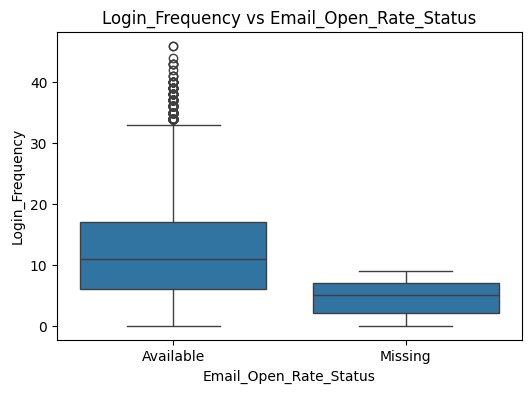

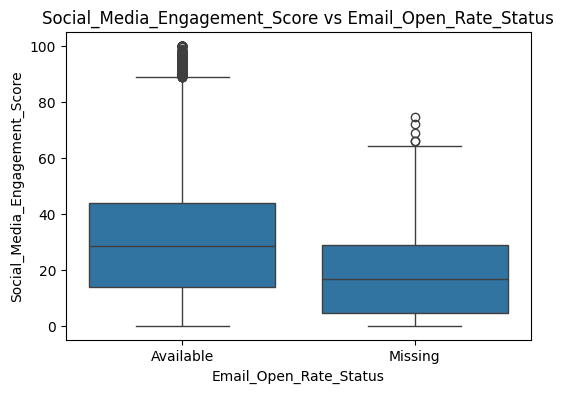

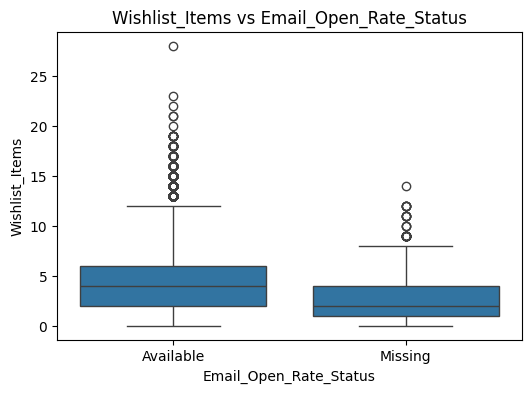

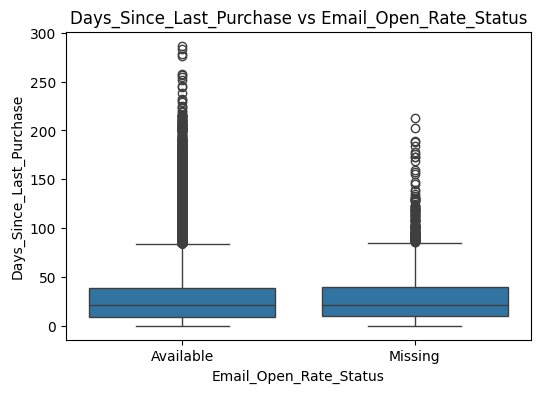

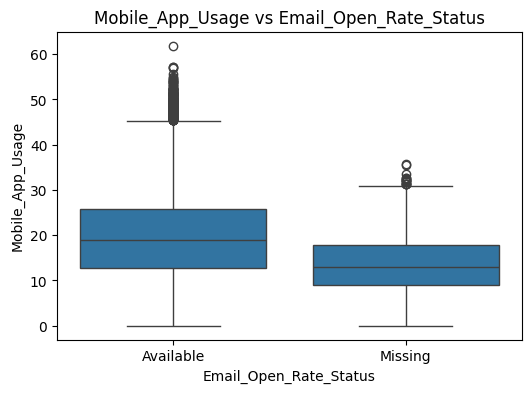

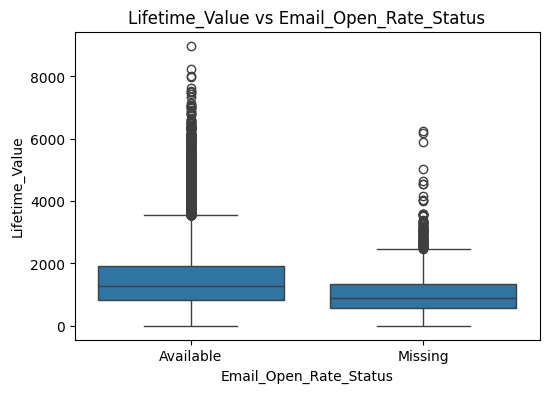

In [136]:
features = [
    "Login_Frequency",
    "Social_Media_Engagement_Score",
    "Wishlist_Items",
    "Days_Since_Last_Purchase",
    "Mobile_App_Usage",
    "Lifetime_Value"
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="Email_Open_Rate_Status",
        y=col,
        data=df
    )

    plt.title(f"{col} vs Email_Open_Rate_Status")

    plt.show()


Missing group = low engagement customers

    ลูกค้าที่ไม่ค่อย active
    → ไม่เปิด email
    → ไม่มี email open rate

ไม่ใช่ random missing ช Missing Not At Random (MNAR)

สร้าง indicator feature Missing_Group (เป็นประโยชน์ แก่ Model)

In [137]:
df["Email_Open_Rate_Missing"] = df["Email_Open_Rate"].isna().astype(int)

df["Email_Open_Rate"] = df["Email_Open_Rate"].fillna(
    df["Email_Open_Rate"].median()
)

Customers with missing Email_Open_Rate tend to have lower engagement
levels across multiple behavioral metrics such as login frequency,
mobile app usage, and social media engagement.

This suggests that the missing values are likely associated with
low customer engagement rather than occurring completely at random.

To preserve the dataset structure, median imputation was applied
along with a missing indicator feature.


In [144]:
df[
[
"Product_Reviews_Written",
"Social_Media_Engagement_Score",
"Mobile_App_Usage"
]
].isna().sum(axis=1).value_counts()



0    36833
1    11874
2     1253
3       40
Name: count, dtype: int64

missing ของแต่ละ column
แทบไม่สัมพันธ์กันเลย >> Product_Reviews_Written หาย
ไม่ได้แปลว่า Social หรือ Mobile จะหายด้วย

missing ≈ random


In [145]:
print("Missing values in Product_Reviews_Written, Social_Media_Engagement_Score, Mobile_App_Usage:")
missing = df[
[
"Product_Reviews_Written",
"Social_Media_Engagement_Score",
"Mobile_App_Usage"
]
].isna()

missing.corr()



Missing values in Product_Reviews_Written, Social_Media_Engagement_Score, Mobile_App_Usage:


,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage
Product_Reviews_Written,1.000000,-0.000724,-0.003658
Social_Media_Engagement_Score,-0.000724,1.000000,0.004103
Mobile_App_Usage,-0.003658,0.004103,1.000000


ส่วนใหญ่ไม่มี missing


<Axes: >

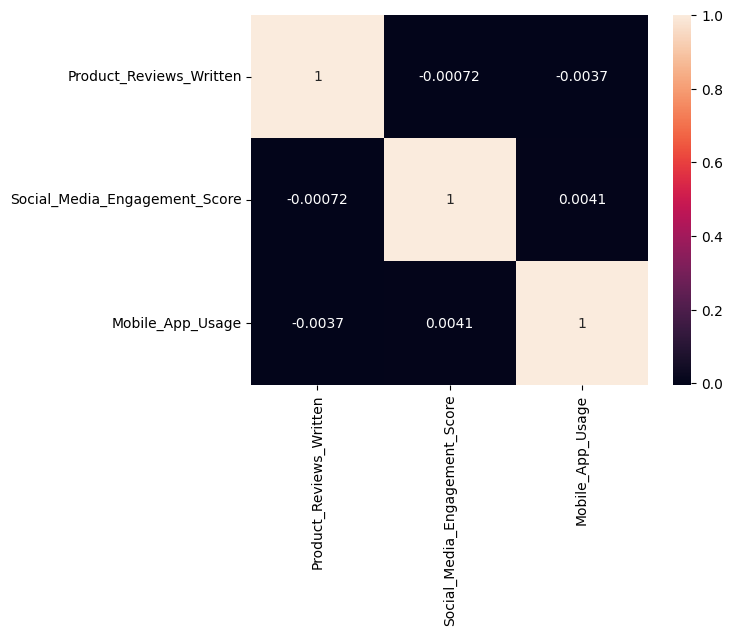

In [143]:
sns.heatmap(
    df[
    [
    "Product_Reviews_Written",
    "Social_Media_Engagement_Score",
    "Mobile_App_Usage"
    ]
    ].isna().corr(),
    annot=True
)

missing ไม่ได้เกิดเป็น cluster
missing แทบจะสุ่ม

Missing values in numeric features were imputed using the median.
Further correlation analysis was considered but skipped due to
low missing ratio and absence of strong missing patterns.  down their

In [149]:
cols = [
    "Product_Reviews_Written",
    "Social_Media_Engagement_Score",
    "Mobile_App_Usage"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

df[cols].isna().sum()

Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
dtype: int64

In [151]:
df["Customer_Service_Calls"] = df["Customer_Service_Calls"].fillna(
    df["Customer_Service_Calls"].median()
)

In [152]:
df["Payment_Method_Diversity"] = df["Payment_Method_Diversity"].fillna(
    df["Payment_Method_Diversity"].median()
)

In [153]:
df["Credit_Balance"] = df["Credit_Balance"].fillna(
    df["Credit_Balance"].median()
)


In [154]:
df.isna().sum().sort_values(ascending=False)


Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
Session_Status                   0
Pages_Status                     0
Wishlist_item_Status             0
Email_Open_Rate_Stat